# CNN전이학습_data_augmentation
* 전이학습: 사전에 훈련된 모델을 가져와서 사용하는 것
* data_agmentation: 이미지 데이터의 경우 데이터가 적어서 확보가 어려움, 비쌈, 기존 이미지데이터에 변형을 가해서 데이터 수를 늘리는 작업(회전, 확대, 축소, 자르기)

# Image Augmentation
* 학습데이터 부족을 해결하기 위해서 이미지에 변형을 가해 새로운 이미지를 만들어 주는 것

In [1]:
from keras.preprocessing.image import img_to_array, array_to_img, load_img
from tensorflow.keras.preprocessing.image import ImageDataGenerator

In [5]:
image = load_img("./data/catanddog/bird.jpg")
image_array = img_to_array(image)
image_array.shape

(703, 454, 3)

In [6]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

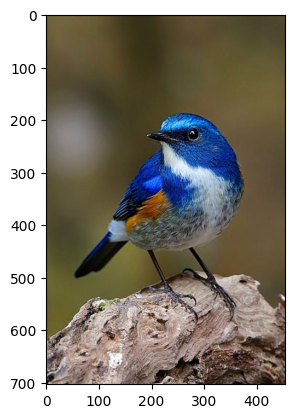

In [7]:
plt.imshow(image)
plt.show()

이미지 증폭

In [8]:
imggen = ImageDataGenerator(
        rescale=1./255,
        rotation_range=40,
        width_shift_range=0.3,
        height_shift_range=0.2,
        shear_range=0.6,
        zoom_range=0.3,
        horizontal_flip=True,
        vertical_flip=True,
        fill_mode='nearest')

이미지 차원 늘리기

In [9]:
image_array.shape

(703, 454, 3)

In [10]:
(1, ) + image_array.shape

(1, 703, 454, 3)

In [12]:
image_array.reshape((1,) + image_array.shape).shape

(1, 703, 454, 3)

In [13]:
image_array = image_array.reshape((1,) + image_array.shape)
image_array.shape

(1, 703, 454, 3)

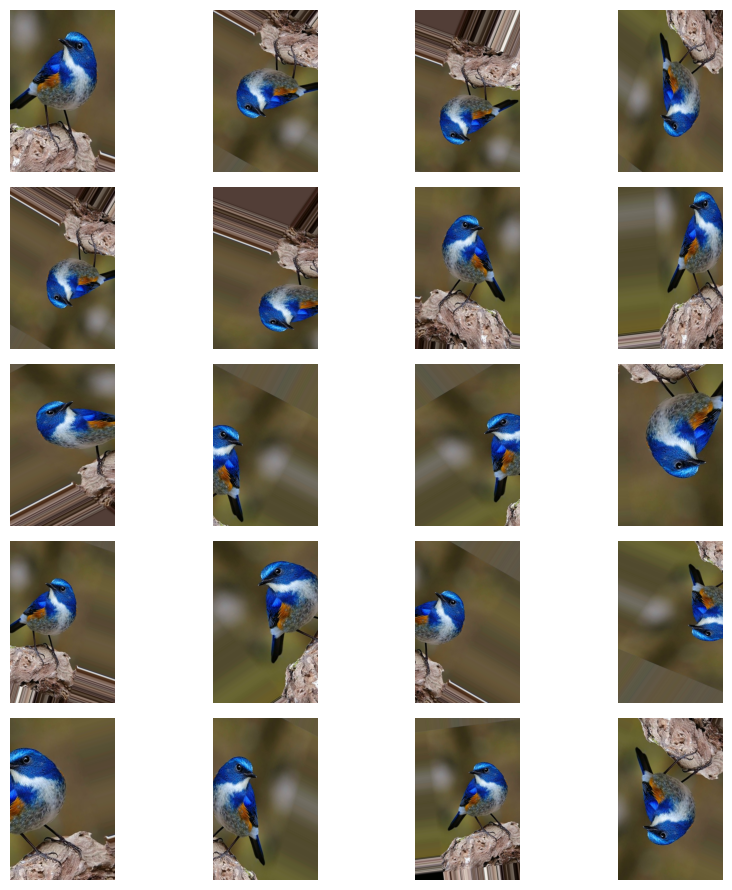

In [14]:
fig, axes = plt.subplots(5, 4, figsize=(9,9))
axes = axes.ravel()

for i, batch in enumerate(imggen.flow(image_array, batch_size=1)):
    if i >= 20:
        break
    augmented_image = array_to_img(batch[0])
    axes[i].imshow(augmented_image)
    axes[i].axis('off')
plt.tight_layout()
plt.show()

# image_augmentation을 이용한 개/고양이 분류 모델 만들기

In [15]:
# 데이터 로드
train_dir = "./data/catanddog/train/"
valid_dir = "./data/catanddog/validation/"
batch_size = 16 # 한 번에 불러오는 사진의 개수 16 - 32 개 사이로 지정
image_size = (224, 224)  # 모델의 입력 크기에 맞춤

In [17]:
# 이미지 증강 훈련데이터에만 적용
train_aug = ImageDataGenerator(
        rescale=1./255,
        rotation_range=40,
        width_shift_range=0.3,
        height_shift_range=0.2,
        shear_range=0.6,
        zoom_range=0.3,
        horizontal_flip=True,
        vertical_flip=True,
        fill_mode='nearest'
        )

valid_aug = ImageDataGenerator(rescale=1./255)

# 모든 데이터에 이미지 증강
train_gen = train_aug.flow_from_directory(
            train_dir,
            target_size=image_size,
            batch_size=batch_size,
            class_mode='categorical',
            shuffle=True,
            seed=42
            )

valid_gen = valid_aug.flow_from_directory(
            valid_dir,
            target_size=image_size,
            batch_size=batch_size,
            class_mode='categorical',
            shuffle=True,
            seed=42
            )

X_batch, y_batch = next(train_gen)
print(X_batch.shape)
print(y_batch.shape)
print(train_gen.class_indices)


Found 385 images belonging to 2 classes.
Found 98 images belonging to 2 classes.
(16, 224, 224, 3)
(16, 2)
{'Cat': 0, 'Dog': 1}


# CNN을 이용한 개/고양이 분류

In [18]:
from keras.models import Sequential, load_model
from keras.layers import Conv2D, MaxPooling2D, Flatten, Dense, Input, Dropout, BatchNormalization
from keras.callbacks import EarlyStopping, ModelCheckpoint

In [22]:
model = Sequential()
model.add(Input(shape=X_batch.shape[1:]))
model.add(Conv2D(32, kernel_size=(3,3), activation='relu'))
model.add(BatchNormalization())
model.add(Conv2D(32, kernel_size=(3,3), activation='relu'))
model.add(BatchNormalization())
model.add(MaxPooling2D(pool_size=(2, 2), strides=2))
model.add(Dropout(0.25))
model.add(Conv2D(64, kernel_size=(3,3), activation='relu'))
model.add(BatchNormalization())
model.add(Conv2D(64, kernel_size=(3,3), activation='relu'))
model.add(BatchNormalization())
model.add(MaxPooling2D(pool_size=(2, 2), strides=2))
model.add(Dropout(0.25))
model.add(Conv2D(32, kernel_size=(3,3), activation='relu'))
model.add(BatchNormalization())
model.add(Conv2D(32, kernel_size=(3,3), activation='relu'))
model.add(BatchNormalization())
model.add(MaxPooling2D(pool_size=(2, 2), strides=2))
model.add(Dropout(0.25))
model.add(Flatten())
model.add(Dense(128, activation='relu'))
model.add(BatchNormalization())
model.add(Dropout(0.25))
model.add(Dense(64, activation='relu'))
model.add(Dense(2, activation='softmax'))
model.summary()

Model: "sequential_2"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d_12 (Conv2D)              │ (None, 222, 222, 32)   │           896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_13          │ (None, 222, 222, 32)   │           128 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_13 (Conv2D)              │ (None, 220, 220, 32)   │         9,248 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_14          │ (None, 220, 220, 32)   │           128 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_6 (MaxPooling2D)  │ (None, 110, 110, 32)   │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_7 (Dropout)             │ (None, 110, 110, 32)   │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_14 (Conv2D)              │ (None, 108, 108, 64)   │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_15          │ (None, 108, 108, 64)   │           256 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_15 (Conv2D)              │ (None, 106, 106, 64)   │        36,928 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_16          │ (None, 106, 106, 64)   │           256 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_7 (MaxPooling2D)  │ (None, 53, 53, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_8 (Dropout)             │ (None, 53, 53, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_16 (Conv2D)              │ (None, 51, 51, 32)     │        18,464 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_17          │ (None, 51, 51, 32)     │           128 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_17 (Conv2D)              │ (None, 49, 49, 32)     │         9,248 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_18          │ (None, 49, 49, 32)     │           128 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_8 (MaxPooling2D)  │ (None, 24, 24, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_9 (Dropout)             │ (None, 24, 24, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten_2 (Flatten)             │ (None, 18432)          │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_4 (Dense)                 │ (None, 128)            │     2,359,424 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_19          │ (None, 128)            │           512 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼─────────────

 Total params: 2,462,626 (9.39 MB)

 Trainable params: 2,461,858 (9.39 MB)

 Non-trainable params: 768 (3.00 KB)

Epoch 1/1000


2026-03-20 11:32:06.531963: I external/local_xla/xla/service/service.cc:163] XLA service 0x7f57b001b580 initialized for platform CUDA (this does not guarantee that XLA will be used). Devices:
2026-03-20 11:32:06.532081: I external/local_xla/xla/service/service.cc:171]   StreamExecutor device (0): NVIDIA GeForce RTX 3060 Laptop GPU, Compute Capability 8.6
2026-03-20 11:32:06.650147: I tensorflow/compiler/mlir/tensorflow/utils/dump_mlir_util.cc:269] disabling MLIR crash reproducer, set env var `MLIR_CRASH_REPRODUCER_DIRECTORY` to enable.
2026-03-20 11:32:07.316934: I external/local_xla/xla/stream_executor/cuda/cuda_dnn.cc:473] Loaded cuDNN version 92000


 1/25 ━━━━━━━━━━━━━━━━━━━━ 7:30 19s/step - accuracy: 0.5000 - loss: 1.0222

I0000 00:00:1773973940.231556   22802 device_compiler.h:196] Compiled cluster using XLA!  This line is logged at most once for the lifetime of the process.


25/25 ━━━━━━━━━━━━━━━━━━━━ 44s 1s/step - accuracy: 0.4909 - loss: 0.8836 - val_accuracy: 0.5000 - val_loss: 0.6931
Epoch 2/1000
25/25 ━━━━━━━━━━━━━━━━━━━━ 7s 292ms/step - accuracy: 0.5481 - loss: 0.7601 - val_accuracy: 0.5000 - val_loss: 0.7454
Epoch 3/1000
25/25 ━━━━━━━━━━━━━━━━━━━━ 8s 303ms/step - accuracy: 0.5403 - loss: 0.7634 - val_accuracy: 0.5000 - val_loss: 0.9475
Epoch 4/1000
25/25 ━━━━━━━━━━━━━━━━━━━━ 8s 314ms/step - accuracy: 0.5455 - loss: 0.8064 - val_accuracy: 0.5000 - val_loss: 0.9576
Epoch 5/1000
25/25 ━━━━━━━━━━━━━━━━━━━━ 7s 287ms/step - accuracy: 0.5740 - loss: 0.7302 - val_accuracy: 0.5000 - val_loss: 0.7114
Epoch 6/1000
25/25 ━━━━━━━━━━━━━━━━━━━━ 8s 325ms/step - accuracy: 0.5948 - loss: 0.6911 - val_accuracy: 0.5714 - val_loss: 0.6828
Epoch 7/1000
25/25 ━━━━━━━━━━━━━━━━━━━━ 7s 288ms/step - accuracy: 0.6104 - loss: 0.6723 - val_accuracy: 0.4286 - val_loss: 0.8035
Epoch 8/1000
25/25 ━━━━━━━━━━━━━━━━━━━━ 8s 308ms/step - accuracy: 0.6052 - loss: 0.7014 - val_accuracy: 0

Epoch 51/1000
25/25 ━━━━━━━━━━━━━━━━━━━━ 7s 265ms/step - accuracy: 0.6935 - loss: 0.5530 - val_accuracy: 0.6633 - val_loss: 0.6249
Epoch 52/1000
25/25 ━━━━━━━━━━━━━━━━━━━━ 7s 304ms/step - accuracy: 0.7299 - loss: 0.5711 - val_accuracy: 0.5714 - val_loss: 0.9194
Epoch 53/1000
25/25 ━━━━━━━━━━━━━━━━━━━━ 7s 272ms/step - accuracy: 0.6883 - loss: 0.5500 - val_accuracy: 0.5714 - val_loss: 1.0388
Epoch 54/1000
25/25 ━━━━━━━━━━━━━━━━━━━━ 7s 275ms/step - accuracy: 0.6416 - loss: 0.6085 - val_accuracy: 0.6224 - val_loss: 0.6838
Epoch 55/1000
25/25 ━━━━━━━━━━━━━━━━━━━━ 7s 271ms/step - accuracy: 0.6597 - loss: 0.6123 - val_accuracy: 0.5918 - val_loss: 0.6962
Epoch 56/1000
25/25 ━━━━━━━━━━━━━━━━━━━━ 7s 260ms/step - accuracy: 0.7688 - loss: 0.5136 - val_accuracy: 0.6735 - val_loss: 0.6186
Epoch 57/1000
25/25 ━━━━━━━━━━━━━━━━━━━━ 11s 300ms/step - accuracy: 0.7377 - loss: 0.5558 - val_accuracy: 0.7041 - val_loss: 0.5210
Epoch 58/1000
25/25 ━━━━━━━━━━━━━━━━━━━━ 7s 282ms/step - accuracy: 0.6883 - loss: 

25/25 ━━━━━━━━━━━━━━━━━━━━ 7s 292ms/step - accuracy: 0.7247 - loss: 0.5253 - val_accuracy: 0.6531 - val_loss: 0.6290
Epoch 101/1000
25/25 ━━━━━━━━━━━━━━━━━━━━ 7s 295ms/step - accuracy: 0.7455 - loss: 0.5002 - val_accuracy: 0.6837 - val_loss: 0.7014
Epoch 102/1000
25/25 ━━━━━━━━━━━━━━━━━━━━ 8s 331ms/step - accuracy: 0.7584 - loss: 0.4931 - val_accuracy: 0.7041 - val_loss: 0.6474
Epoch 103/1000
25/25 ━━━━━━━━━━━━━━━━━━━━ 8s 304ms/step - accuracy: 0.7299 - loss: 0.5278 - val_accuracy: 0.6633 - val_loss: 0.6228
Epoch 104/1000
25/25 ━━━━━━━━━━━━━━━━━━━━ 7s 274ms/step - accuracy: 0.7403 - loss: 0.5326 - val_accuracy: 0.6939 - val_loss: 0.7305
Epoch 105/1000
25/25 ━━━━━━━━━━━━━━━━━━━━ 7s 294ms/step - accuracy: 0.7532 - loss: 0.5116 - val_accuracy: 0.6327 - val_loss: 1.0224
Epoch 106/1000
25/25 ━━━━━━━━━━━━━━━━━━━━ 8s 300ms/step - accuracy: 0.7247 - loss: 0.5331 - val_accuracy: 0.6327 - val_loss: 0.8404
Epoch 107/1000
25/25 ━━━━━━━━━━━━━━━━━━━━ 7s 290ms/step - accuracy: 0.7506 - loss: 0.5089 -

25/25 ━━━━━━━━━━━━━━━━━━━━ 7s 263ms/step - accuracy: 0.8052 - loss: 0.4306 - val_accuracy: 0.7143 - val_loss: 0.6043
Epoch 150/1000
25/25 ━━━━━━━━━━━━━━━━━━━━ 7s 277ms/step - accuracy: 0.7948 - loss: 0.4519 - val_accuracy: 0.6633 - val_loss: 0.7314
Epoch 151/1000
25/25 ━━━━━━━━━━━━━━━━━━━━ 7s 288ms/step - accuracy: 0.7558 - loss: 0.4858 - val_accuracy: 0.7143 - val_loss: 0.5755
Epoch 152/1000
25/25 ━━━━━━━━━━━━━━━━━━━━ 7s 263ms/step - accuracy: 0.7792 - loss: 0.4794 - val_accuracy: 0.7041 - val_loss: 0.5782
Epoch 153/1000
25/25 ━━━━━━━━━━━━━━━━━━━━ 7s 276ms/step - accuracy: 0.7740 - loss: 0.4791 - val_accuracy: 0.5306 - val_loss: 1.2036
Epoch 154/1000
25/25 ━━━━━━━━━━━━━━━━━━━━ 7s 257ms/step - accuracy: 0.7818 - loss: 0.4485 - val_accuracy: 0.6224 - val_loss: 0.9653
Epoch 155/1000
25/25 ━━━━━━━━━━━━━━━━━━━━ 7s 273ms/step - accuracy: 0.8078 - loss: 0.4358 - val_accuracy: 0.6735 - val_loss: 0.6129
Epoch 156/1000
25/25 ━━━━━━━━━━━━━━━━━━━━ 8s 311ms/step - accuracy: 0.7844 - loss: 0.4544 -

25/25 ━━━━━━━━━━━━━━━━━━━━ 8s 292ms/step - accuracy: 0.8156 - loss: 0.3933 - val_accuracy: 0.7449 - val_loss: 0.6122
Epoch 199/1000
25/25 ━━━━━━━━━━━━━━━━━━━━ 7s 277ms/step - accuracy: 0.8416 - loss: 0.3519 - val_accuracy: 0.6735 - val_loss: 0.7147
Epoch 200/1000
25/25 ━━━━━━━━━━━━━━━━━━━━ 7s 281ms/step - accuracy: 0.8286 - loss: 0.3759 - val_accuracy: 0.6429 - val_loss: 0.7491
Epoch 201/1000
25/25 ━━━━━━━━━━━━━━━━━━━━ 7s 290ms/step - accuracy: 0.8182 - loss: 0.3919 - val_accuracy: 0.7143 - val_loss: 0.6884
Epoch 202/1000
25/25 ━━━━━━━━━━━━━━━━━━━━ 8s 302ms/step - accuracy: 0.8519 - loss: 0.3563 - val_accuracy: 0.6735 - val_loss: 0.7304
Epoch 203/1000
25/25 ━━━━━━━━━━━━━━━━━━━━ 8s 306ms/step - accuracy: 0.8545 - loss: 0.3836 - val_accuracy: 0.7245 - val_loss: 0.7429
Epoch 204/1000
25/25 ━━━━━━━━━━━━━━━━━━━━ 8s 306ms/step - accuracy: 0.8052 - loss: 0.4387 - val_accuracy: 0.6429 - val_loss: 0.8103
Epoch 205/1000
25/25 ━━━━━━━━━━━━━━━━━━━━ 7s 285ms/step - accuracy: 0.8130 - loss: 0.4284 -

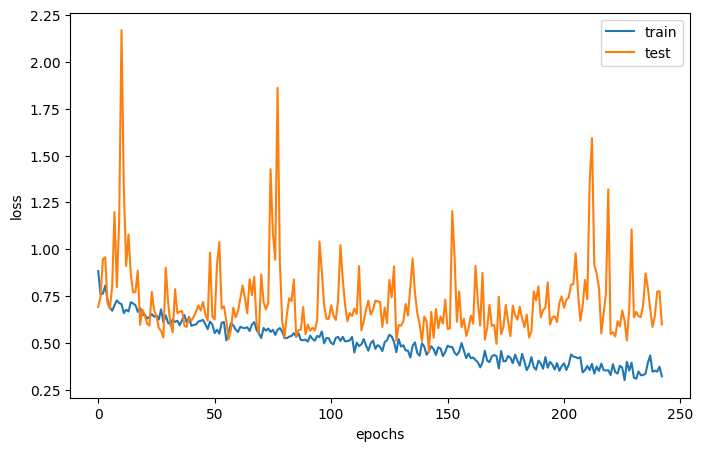

In [24]:
model.compile(loss="categorical_crossentropy",
             optimizer='adam',
             metrics=['accuracy'])
model_path = "./model/catndog_cnn_model.keras"
model_save = ModelCheckpoint(filepath=model_path, save_best_only=True)
early_stop = EarlyStopping(monitor='val_loss', patience=100, restore_best_weights=True)
history = model.fit(train_gen, epochs=1000, validation_data=valid_gen,
                   callbacks=[model_save, early_stop])
plt.figure(figsize=(8,5))
plt.plot(history.history['loss'])
plt.plot(history.history['val_loss'])
plt.xlabel('epochs')
plt.ylabel('loss')
plt.legend(['train', 'test'])
plt.show()

In [25]:
class_indices = valid_gen.class_indices
class_indices

{'Cat': 0, 'Dog': 1}

1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 987ms/step


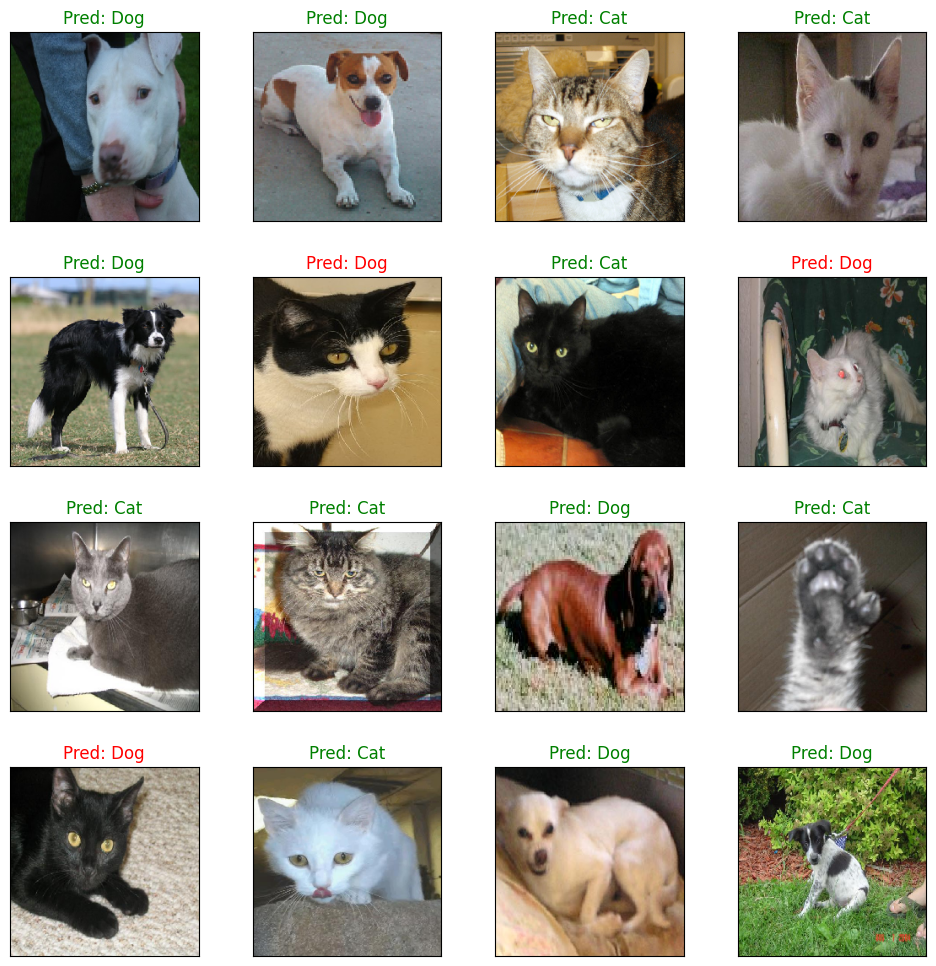


cnn_best_model평가 결과: Loss: 0.4691, Accuracy: 0.8125


In [30]:
# best 모델 로드
cnn_best_model = load_model("./model/catndog_cnn_model.keras")

# 클래스 이름 추출하기
class_indices = valid_gen.class_indices
class_names = [k for k, v in sorted(class_indices.items(), key=lambda x: x[1])]
validation_batch, label_batch = next(iter(valid_gen))

cnn_pred = cnn_best_model.predict(validation_batch)
pred_values = np.argmax(cnn_pred, axis=1)
true_values = np.argmax(label_batch, axis=1)

fig = plt.figure(figsize=(12,12))
fig.subplots_adjust(hspace=0.3)

num_images = min(16, validation_batch.shape[0])

for i in range(num_images):
    ax = fig.add_subplot(4, 4, i + 1, xticks=[], yticks=[])
    ax.imshow(validation_batch[i], cmap=plt.cm.gray_r)
    
    pred_label = class_names[pred_values[i]]
    true_label = class_names[true_values[i]]
    color = 'green' if pred_values[i] == true_values[i] else 'red'
    ax.set_title(f"Pred: {pred_label}", color=color, fontsize=12)
plt.show()

# loss와 accuracy 출력
loss, acc = cnn_best_model.evaluate(validation_batch, label_batch, verbose=0)
print(f"\ncnn_best_model평가 결과: Loss: {loss:.4f}, Accuracy: {acc:.4f}")
    

# 전이학습
* 사전에 훈련된 모델을 가지고 새로운 데이터를 넣어서 튜닝을 하거나 결과를 출력
* keras.applications에 있음

# ResNet50
* ResNet50에 사용할 경우, rescale=1./255는 제거하고 preprocessing_function=preprocess_input을 사용
* Keras의 ResNet50은 입력 이미지를 BGR로 바꾸고 채널별 평균을 빼는 전처리를 필요로 하기 때문

In [31]:
from tensorflow.keras.layers import GlobalMaxPooling2D, GlobalAveragePooling2D
from tensorflow.keras.applications import ResNet50, ResNet152V2
from tensorflow.keras.applications.resnet import preprocess_input
import tensorflow as tf

In [32]:
# ✅ ResNet50에 맞는 이미지 증강기 (rescale 제거 → preprocess_input 사용)
train_aug = ImageDataGenerator(
    preprocessing_function=preprocess_input,  # ✔️ ResNet 전용 전처리
    rotation_range=40,
    width_shift_range=0.3,
    height_shift_range=0.2,
    shear_range=0.6,
    zoom_range=0.3,
    fill_mode='nearest'
)

valid_aug = ImageDataGenerator(
    preprocessing_function=preprocess_input  # ✔️ Validation도 동일하게 처리
)

# ✅ 이미지 제너레이터 생성
train_gen = train_aug.flow_from_directory(
    train_dir,
    target_size=image_size,  # 예: (224, 224)
    batch_size=batch_size,
    class_mode='categorical',
    shuffle=True,
    seed=42
)

valid_gen = valid_aug.flow_from_directory(
    valid_dir,
    target_size=image_size,
    batch_size=batch_size,
    class_mode='categorical',
    shuffle=True,
    seed=42
)

# ✅ 배치 확인
X_batch, y_batch = next(train_gen)
print(X_batch.shape)  # 예: (32, 224, 224, 3)
print(y_batch.shape)
print(train_gen.class_indices)

Found 385 images belonging to 2 classes.
Found 98 images belonging to 2 classes.
(16, 224, 224, 3)
(16, 2)
{'Cat': 0, 'Dog': 1}


In [33]:
base_model = ResNet50(
    include_top=False,
    weights='imagenet',
    input_tensor=None,
    input_shape=(224,224,3),
    pooling='avg')

In [34]:
base_model.summary()

Model: "resnet50"

┏━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)        ┃ Output Shape      ┃    Param # ┃ Connected to      ┃
┡━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━┩
│ input_layer_3       │ (None, 224, 224,  │          0 │ -                 │
│ (InputLayer)        │ 3)                │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv1_pad           │ (None, 230, 230,  │          0 │ input_layer_3[0]… │
│ (ZeroPadding2D)     │ 3)                │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv1_conv (Conv2D) │ (None, 112, 112,  │      9,472 │ conv1_pad[0][0]   │
│                     │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv1_bn            │ (None, 112, 112,  │        256 │ conv1_conv[0][0]  │
│ (BatchNormalizatio… │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv1_relu          │ (None, 112, 112,  │          0 │ conv1_bn[0][0]    │
│ (Activation)        │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ pool1_pad           │ (None, 114, 114,  │          0 │ conv1_relu[0][0]  │
│ (ZeroPadding2D)     │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ pool1_pool          │ (None, 56, 56,    │          0 │ pool1_pad[0][0]   │
│ (MaxPooling2D)      │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2_block1_1_conv │ (None, 56, 56,    │      4,160 │ pool1_pool[0][0]  │
│ (Conv2D)            │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2_block1_1_bn   │ (None, 56, 56,    │        256 │ conv2_block1_1_c… │
│ (BatchNormalizatio… │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2_block1_1_relu │ (None, 56, 56,    │          0 │ conv2_block1_1_b… │
│ (Activation)        │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2_block1_2_conv │ (None, 56, 56,    │     36,928 │ conv2_block1_1_r… │
│ (Conv2D)            │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2_block1_2_bn   │ (None, 56, 56,    │        256 │ conv2_block1_2_c… │
│ (BatchNormalizatio… │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2_block1_2_relu │ (None, 56, 56,    │          0 │ conv2_block1_2_b… │
│ (Activation)        │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2_block1_0_conv │ (None, 56, 56,    │     16,640 │ pool1_pool[0][0]  │
│ (Conv2D)            │ 256)              │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2_block1_3_conv │ (None, 56, 56,    │     16,640 │ conv2_block1_2_r… │
│ (Conv2D)            │ 256)              │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2_block1_0_bn   │ (None, 56, 56,    │      1,024 │ conv2_block1_0_c… │
│ (BatchNormalizatio… │ 256)              │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2_block1_3_bn   │ (None, 56, 56,    │      1,024 │ conv2_block1_3_c

 Total params: 23,587,712 (89.98 MB)

 Trainable params: 23,534,592 (89.78 MB)

 Non-trainable params: 53,120 (207.50 KB)

In [35]:
base_model.trainable = False
res50_model = Sequential()
res50_model.add(base_model)
res50_model.add(Dense(2, activation='softmax'))
res50_model.summary()

Model: "sequential_3"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ resnet50 (Functional)           │ (None, 2048)           │    23,587,712 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_7 (Dense)                 │ (None, 2)              │         4,098 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 23,591,810 (90.00 MB)

 Trainable params: 4,098 (16.01 KB)

 Non-trainable params: 23,587,712 (89.98 MB)

Epoch 1/1000
25/25 ━━━━━━━━━━━━━━━━━━━━ 0s 376ms/step - accuracy: 0.5781 - loss: 0.7368
Epoch 1: val_loss improved from None to 0.50315, saving model to ./model/res50_catndog.keras

Epoch 1: finished saving model to ./model/res50_catndog.keras
25/25 ━━━━━━━━━━━━━━━━━━━━ 29s 753ms/step - accuracy: 0.6338 - loss: 0.6760 - val_accuracy: 0.7653 - val_loss: 0.5031
Epoch 2/1000
25/25 ━━━━━━━━━━━━━━━━━━━━ 0s 247ms/step - accuracy: 0.7704 - loss: 0.5021
Epoch 2: val_loss improved from 0.50315 to 0.36949, saving model to ./model/res50_catndog.keras

Epoch 2: finished saving model to ./model/res50_catndog.keras
25/25 ━━━━━━━━━━━━━━━━━━━━ 9s 351ms/step - accuracy: 0.7818 - loss: 0.4854 - val_accuracy: 0.8571 - val_loss: 0.3695
Epoch 3/1000
25/25 ━━━━━━━━━━━━━━━━━━━━ 0s 251ms/step - accuracy: 0.8253 - loss: 0.4428
Epoch 3: val_loss improved from 0.36949 to 0.28709, saving model to ./model/res50_catndog.keras

Epoch 3: finished saving model to ./model/res50_catndog.keras
25/25 ━━━━━━━━━━━━━━━━━━━━ 

Epoch 20/1000
25/25 ━━━━━━━━━━━━━━━━━━━━ 0s 240ms/step - accuracy: 0.9738 - loss: 0.0912
Epoch 20: val_loss improved from 0.08915 to 0.08264, saving model to ./model/res50_catndog.keras

Epoch 20: finished saving model to ./model/res50_catndog.keras
25/25 ━━━━━━━━━━━━━━━━━━━━ 9s 355ms/step - accuracy: 0.9792 - loss: 0.0898 - val_accuracy: 0.9796 - val_loss: 0.0826
Epoch 21/1000
25/25 ━━━━━━━━━━━━━━━━━━━━ 0s 258ms/step - accuracy: 0.9739 - loss: 0.1051
Epoch 21: val_loss did not improve from 0.08264
25/25 ━━━━━━━━━━━━━━━━━━━━ 8s 318ms/step - accuracy: 0.9714 - loss: 0.1004 - val_accuracy: 0.9796 - val_loss: 0.0833
Epoch 22/1000
25/25 ━━━━━━━━━━━━━━━━━━━━ 0s 244ms/step - accuracy: 0.9891 - loss: 0.0941
Epoch 22: val_loss improved from 0.08264 to 0.07706, saving model to ./model/res50_catndog.keras

Epoch 22: finished saving model to ./model/res50_catndog.keras
25/25 ━━━━━━━━━━━━━━━━━━━━ 9s 365ms/step - accuracy: 0.9766 - loss: 0.0981 - val_accuracy: 0.9898 - val_loss: 0.0771
Epoch 23/100

Epoch 42/1000
25/25 ━━━━━━━━━━━━━━━━━━━━ 0s 245ms/step - accuracy: 0.9921 - loss: 0.0427
Epoch 42: val_loss did not improve from 0.05944
25/25 ━━━━━━━━━━━━━━━━━━━━ 7s 281ms/step - accuracy: 0.9792 - loss: 0.0556 - val_accuracy: 0.9898 - val_loss: 0.0628
Epoch 43/1000
25/25 ━━━━━━━━━━━━━━━━━━━━ 0s 259ms/step - accuracy: 0.9890 - loss: 0.0483
Epoch 43: val_loss did not improve from 0.05944
25/25 ━━━━━━━━━━━━━━━━━━━━ 8s 298ms/step - accuracy: 0.9896 - loss: 0.0485 - val_accuracy: 0.9898 - val_loss: 0.0605
Epoch 44/1000
25/25 ━━━━━━━━━━━━━━━━━━━━ 0s 221ms/step - accuracy: 0.9856 - loss: 0.0529
Epoch 44: val_loss did not improve from 0.05944
25/25 ━━━━━━━━━━━━━━━━━━━━ 7s 259ms/step - accuracy: 0.9740 - loss: 0.0659 - val_accuracy: 0.9898 - val_loss: 0.0605
Epoch 45/1000
25/25 ━━━━━━━━━━━━━━━━━━━━ 0s 248ms/step - accuracy: 0.9984 - loss: 0.0436
Epoch 45: val_loss did not improve from 0.05944
25/25 ━━━━━━━━━━━━━━━━━━━━ 7s 288ms/step - accuracy: 0.9948 - loss: 0.0431 - val_accuracy: 0.9898 - v

25/25 ━━━━━━━━━━━━━━━━━━━━ 7s 272ms/step - accuracy: 0.9948 - loss: 0.0365 - val_accuracy: 0.9898 - val_loss: 0.0550
Epoch 67/1000
25/25 ━━━━━━━━━━━━━━━━━━━━ 0s 247ms/step - accuracy: 0.9891 - loss: 0.0484
Epoch 67: val_loss did not improve from 0.05159
25/25 ━━━━━━━━━━━━━━━━━━━━ 7s 292ms/step - accuracy: 0.9844 - loss: 0.0552 - val_accuracy: 0.9796 - val_loss: 0.0565
Epoch 68/1000
25/25 ━━━━━━━━━━━━━━━━━━━━ 0s 240ms/step - accuracy: 0.9929 - loss: 0.0292
Epoch 68: val_loss did not improve from 0.05159
25/25 ━━━━━━━━━━━━━━━━━━━━ 7s 282ms/step - accuracy: 0.9896 - loss: 0.0336 - val_accuracy: 0.9796 - val_loss: 0.0579
Epoch 69/1000
25/25 ━━━━━━━━━━━━━━━━━━━━ 0s 253ms/step - accuracy: 0.9822 - loss: 0.0389
Epoch 69: val_loss did not improve from 0.05159
25/25 ━━━━━━━━━━━━━━━━━━━━ 8s 302ms/step - accuracy: 0.9844 - loss: 0.0377 - val_accuracy: 0.9898 - val_loss: 0.0569
Epoch 70/1000
25/25 ━━━━━━━━━━━━━━━━━━━━ 0s 258ms/step - accuracy: 0.9997 - loss: 0.0231
Epoch 70: val_loss did not impro

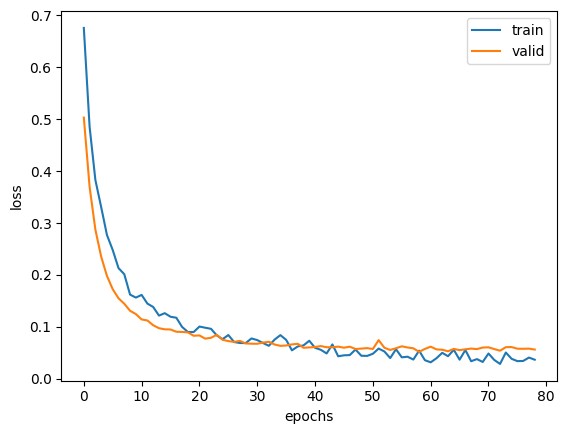

In [36]:
res50_model.compile(loss='categorical_crossentropy', 
                  optimizer=tf.keras.optimizers.Adam(learning_rate=1e-4),
                  metrics=['accuracy'])
model_path = "./model/res50_catndog.keras"
check_point = ModelCheckpoint(model_path, save_best_only=True, monitor='val_loss', verbose=1)
early_stop = EarlyStopping(monitor='val_loss', patience=20, restore_best_weights=True, verbose=1)
res50_history = res50_model.fit(train_gen, epochs=1000, validation_data=valid_gen,
                           callbacks=[early_stop, check_point])
plt.plot(res50_history.history['loss'])
plt.plot(res50_history.history['val_loss'])
plt.xlabel('epochs')
plt.ylabel('loss')
plt.legend(['train', 'valid'])
plt.show()

7/7 ━━━━━━━━━━━━━━━━━━━━ 7s 627ms/step

[전체 Validation Accuracy] 0.4592
1/1 ━━━━━━━━━━━━━━━━━━━━ 4s 4s/step


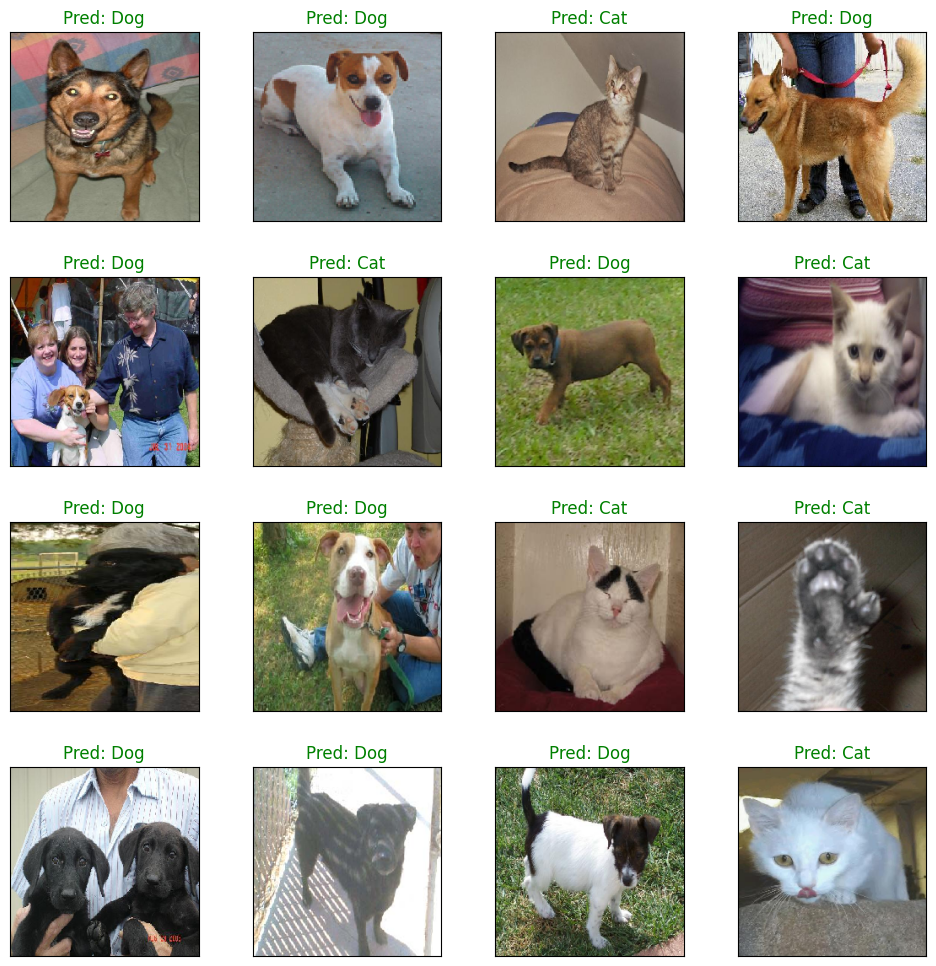

7/7 ━━━━━━━━━━━━━━━━━━━━ 7s 422ms/step - accuracy: 0.9898 - loss: 0.0516

[모델 평가 결과] Loss: 0.0516, Accuracy: 0.9898


In [39]:
from sklearn.metrics import accuracy_score
# ✅ 모델 로드
res50_best_model = load_model("./model/res50_catndog.keras")

# ✅ 클래스 이름 추출
class_indices = valid_gen.class_indices
class_names = [k for k, v in sorted(class_indices.items(), key=lambda x: x[1])]

# ✅ 전체 validation 데이터로 예측
cnn_pred = res50_best_model.predict(valid_gen, verbose=1)
pred_values = np.argmax(cnn_pred, axis=1)
true_values = valid_gen.classes  # 전체 정답

# ✅ 정확도 출력
acc = accuracy_score(true_values, pred_values)
print(f"\n[전체 Validation Accuracy] {acc:.4f}")

# ✅ 시각화용: 소량 배치만 가져오기
sample_batch, label_batch = next(valid_gen)
sample_pred = res50_best_model.predict(sample_batch)
sample_pred_values = np.argmax(sample_pred, axis=1)
sample_true_values = np.argmax(label_batch, axis=1)

# ✅ 시각화: 이미지 복구 후 출력
def deprocess_input(x):
    """ResNet의 preprocess_input을 반대로 적용 (BGR→RGB + 평균값 복원)"""
    x = x.copy()
    # ImageNet 평균값 (BGR 순)
    mean = [103.939, 116.779, 123.68]
    x[..., 0] += mean[0]  # B
    x[..., 1] += mean[1]  # G
    x[..., 2] += mean[2]  # R
    x = x[..., ::-1]  # BGR → RGB
    return np.clip(x / 255.0, 0, 1)  # matplotlib은 0~1 사이값을 기대함

# ✅ 이미지 시각화
fig = plt.figure(figsize=(12, 12))
fig.subplots_adjust(hspace=0.3)
num_images = min(16, sample_batch.shape[0])

for i in range(num_images):
    ax = fig.add_subplot(4, 4, i + 1, xticks=[], yticks=[])
    img = deprocess_input(sample_batch[i])
    ax.imshow(img)
    pred_label = class_names[sample_pred_values[i]]
    true_label = class_names[sample_true_values[i]]
    color = 'green' if pred_label == true_label else 'red'
    ax.set_title(f"Pred: {pred_label}", color=color, fontsize=12)
plt.show()

# ✅ 전체 평가
loss, acc = res50_best_model.evaluate(valid_gen, verbose=1)
print(f"\n[모델 평가 결과] Loss: {loss:.4f}, Accuracy: {acc:.4f}")

# convnextbase로 분석하기
* convnextbase는 내부에 정규화 레이어가 있으므로 입력시 정규화 X
* 데이터 입력시 dtype은 float32 추천

In [40]:
from tensorflow.keras.applications import ConvNeXtBase

In [41]:
# 이미지 증강
train_aug2 = ImageDataGenerator(
            rotation_range=40,
            width_shift_range=0.3,
            height_shift_range=0.2,
            shear_range=0.6,
            zoom_range=0.3,
            fill_mode='nearest',
            dtype='float32')

valid_aug2 = ImageDataGenerator(dtype='float32')

# 이미지 제너레이터
train_gen2 = train_aug2.flow_from_directory(
            train_dir,
            target_size=image_size,
            batch_size=batch_size,
            class_mode='categorical',
            shuffle=True,
            seed=42)

valid_gen2 = valid_aug2.flow_from_directory(
            valid_dir,
            target_size=image_size,
            batch_size=batch_size,
            class_mode='categorical',
            shuffle=True,
            seed=42)


X_batch2, y_batch2 = next(train_gen2)
print(X_batch2.shape)
print(y_batch2.shape)
print(train_gen2.class_indices)

Found 385 images belonging to 2 classes.
Found 98 images belonging to 2 classes.
(16, 224, 224, 3)
(16, 2)
{'Cat': 0, 'Dog': 1}


In [42]:
base_model3 = ConvNeXtBase(
    include_top=False,
    include_preprocessing=True,
    weights="imagenet",
    input_shape=(224,224,3),
    pooling='avg',
    classes=1000,
    classifier_activation="softmax",
    name="convnext_base",
)

In [43]:
base_model3.summary()

Model: "convnext_base"

┏━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)        ┃ Output Shape      ┃    Param # ┃ Connected to      ┃
┡━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━┩
│ input_layer_5       │ (None, 224, 224,  │          0 │ -                 │
│ (InputLayer)        │ 3)                │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ convnext_base_pres… │ (None, 224, 224,  │          0 │ input_layer_5[0]… │
│ (Normalization)     │ 3)                │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ convnext_base_stem  │ (None, 56, 56,    │      6,528 │ convnext_base_pr… │
│ (Sequential)        │ 128)              │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ convnext_base_stag… │ (None, 56, 56,    │      6,400 │ convnext_base_st… │
│ (Conv2D)            │ 128)              │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ convnext_base_stag… │ (None, 56, 56,    │        256 │ convnext_base_st… │
│ (LayerNormalizatio… │ 128)              │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ convnext_base_stag… │ (None, 56, 56,    │     66,048 │ convnext_base_st… │
│ (Dense)             │ 512)              │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ convnext_base_stag… │ (None, 56, 56,    │          0 │ convnext_base_st… │
│ (Activation)        │ 512)              │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ convnext_base_stag… │ (None, 56, 56,    │     65,664 │ convnext_base_st… │
│ (Dense)             │ 128)              │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ convnext_base_stag… │ (None, 56, 56,    │        128 │ convnext_base_st… │
│ (LayerScale)        │ 128)              │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ convnext_base_stag… │ (None, 56, 56,    │          0 │ convnext_base_st… │
│ (Activation)        │ 128)              │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ add (Add)           │ (None, 56, 56,    │          0 │ convnext_base_st… │
│                     │ 128)              │            │ convnext_base_st… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ convnext_base_stag… │ (None, 56, 56,    │      6,400 │ add[0][0]         │
│ (Conv2D)            │ 128)              │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ convnext_base_stag… │ (None, 56, 56,    │        256 │ convnext_base_st… │
│ (LayerNormalizatio… │ 128)              │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ convnext_base_stag… │ (None, 56, 56,    │     66,048 │ convnext_base_st… │
│ (Dense)             │ 512)              │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ convnext_base_stag… │ (None, 56, 56,    │          0 │ convnext_base_st… │
│ (Activation)        │ 512)              │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ convnext_base_stag… │ (None, 56, 56,    │     65,664 │ convnext_base_st… │
│ (Dense)             │ 128)              │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ convnext_base_stag… │ (None, 56, 56,    │        128 │ convnext_base_st

 Total params: 87,566,464 (334.04 MB)

 Trainable params: 87,566,464 (334.04 MB)

 Non-trainable params: 0 (0.00 B)

In [44]:
base_model3.trainable = False
ConvNeXtBase_model = Sequential()
ConvNeXtBase_model.add(base_model3)
ConvNeXtBase_model.add(Dense(2, activation="softmax"))

Epoch 1/1000


2026-03-20 14:13:13.055970: I external/local_xla/xla/stream_executor/cuda/subprocess_compilation.cc:346] ptxas warning : Registers are spilled to local memory in function 'gemm_fusion_dot_67', 12 bytes spill stores, 12 bytes spill loads

2026-03-20 14:13:13.107685: I external/local_xla/xla/stream_executor/cuda/subprocess_compilation.cc:346] ptxas warning : Registers are spilled to local memory in function 'gemm_fusion_dot_12', 704 bytes spill stores, 704 bytes spill loads

2026-03-20 14:13:13.290687: I external/local_xla/xla/stream_executor/cuda/subprocess_compilation.cc:346] ptxas warning : Registers are spilled to local memory in function 'gemm_fusion_dot_6', 64 bytes spill stores, 64 bytes spill loads

2026-03-20 14:13:13.295495: I external/local_xla/xla/stream_executor/cuda/subprocess_compilation.cc:346] ptxas warning : Registers are spilled to local memory in function 'gemm_fusion_dot_12', 64 bytes spill stores, 64 bytes spill loads

2026-03-20 14:13:13.490319: I external/local_xl

13/25 ━━━━━━━━━━━━━━━━━━━━ 3s 260ms/step - accuracy: 0.6068 - loss: 0.8506

2026-03-20 14:13:27.288870: I external/local_xla/xla/stream_executor/cuda/subprocess_compilation.cc:346] ptxas warning : Registers are spilled to local memory in function 'gemm_fusion_dot_6', 4 bytes spill stores, 4 bytes spill loads

2026-03-20 14:13:27.662333: I external/local_xla/xla/stream_executor/cuda/subprocess_compilation.cc:346] ptxas warning : Registers are spilled to local memory in function 'gemm_fusion_dot_67', 840 bytes spill stores, 704 bytes spill loads

2026-03-20 14:13:27.997072: I external/local_xla/xla/stream_executor/cuda/subprocess_compilation.cc:346] ptxas warning : Registers are spilled to local memory in function 'gemm_fusion_dot_12', 64 bytes spill stores, 64 bytes spill loads

2026-03-20 14:13:28.025603: I external/local_xla/xla/stream_executor/cuda/subprocess_compilation.cc:346] ptxas warning : Registers are spilled to local memory in function 'gemm_fusion_dot_7', 44 bytes spill stores, 52 bytes spill loads

2026-03-20 14:13:28.125582: I external/local_xla/x

25/25 ━━━━━━━━━━━━━━━━━━━━ 0s 791ms/step - accuracy: 0.6276 - loss: 0.7812

...


Epoch 1: val_loss improved from None to 0.46376, saving model to ./model/ConvNeXtBase_catndog.keras

Epoch 1: finished saving model to ./model/ConvNeXtBase_catndog.keras
25/25 ━━━━━━━━━━━━━━━━━━━━ 67s 2s/step - accuracy: 0.6857 - loss: 0.6460 - val_accuracy: 0.8061 - val_loss: 0.4638
Epoch 2/1000
25/25 ━━━━━━━━━━━━━━━━━━━━ 0s 245ms/step - accuracy: 0.7783 - loss: 0.4951
Epoch 2: val_loss improved from 0.46376 to 0.32878, saving model to ./model/ConvNeXtBase_catndog.keras

Epoch 2: finished saving model to ./model/ConvNeXtBase_catndog.keras
25/25 ━━━━━━━━━━━━━━━━━━━━ 13s 514ms/step - accuracy: 0.7948 - loss: 0.4479 - val_accuracy: 0.8776 - val_loss: 0.3288
Epoch 3/1000
25/25 ━━━━━━━━━━━━━━━━━━━━ 0s 225ms/step - accuracy: 0.8154 - loss: 0.3693
Epoch 3: val_loss improved from 0.32878 to 0.23979, saving model to ./model/ConvNeXtBase_catndog.keras

Epoch 3: finished saving model to ./model/ConvNeXtBase_catndog.keras
25/25 ━━━━━━━━━━━━━━━━━━━━ 13s 501ms/step - accuracy: 0.8364 - loss: 0.328

25/25 ━━━━━━━━━━━━━━━━━━━━ 12s 491ms/step - accuracy: 0.9870 - loss: 0.0479 - val_accuracy: 0.9796 - val_loss: 0.0637
Epoch 20/1000
25/25 ━━━━━━━━━━━━━━━━━━━━ 0s 231ms/step - accuracy: 0.9914 - loss: 0.0517
Epoch 20: val_loss improved from 0.06368 to 0.06226, saving model to ./model/ConvNeXtBase_catndog.keras

Epoch 20: finished saving model to ./model/ConvNeXtBase_catndog.keras
25/25 ━━━━━━━━━━━━━━━━━━━━ 12s 463ms/step - accuracy: 0.9922 - loss: 0.0440 - val_accuracy: 0.9796 - val_loss: 0.0623
Epoch 21/1000
25/25 ━━━━━━━━━━━━━━━━━━━━ 0s 226ms/step - accuracy: 0.9841 - loss: 0.0791
Epoch 21: val_loss improved from 0.06226 to 0.06070, saving model to ./model/ConvNeXtBase_catndog.keras

Epoch 21: finished saving model to ./model/ConvNeXtBase_catndog.keras
25/25 ━━━━━━━━━━━━━━━━━━━━ 12s 464ms/step - accuracy: 0.9896 - loss: 0.0484 - val_accuracy: 0.9796 - val_loss: 0.0607
Epoch 22/1000
25/25 ━━━━━━━━━━━━━━━━━━━━ 0s 235ms/step - accuracy: 1.0000 - loss: 0.0341
Epoch 22: val_loss improved f

Epoch 38/1000
25/25 ━━━━━━━━━━━━━━━━━━━━ 0s 230ms/step - accuracy: 0.9903 - loss: 0.0213
Epoch 38: val_loss improved from 0.04796 to 0.04716, saving model to ./model/ConvNeXtBase_catndog.keras

Epoch 38: finished saving model to ./model/ConvNeXtBase_catndog.keras
25/25 ━━━━━━━━━━━━━━━━━━━━ 16s 647ms/step - accuracy: 0.9896 - loss: 0.0314 - val_accuracy: 0.9898 - val_loss: 0.0472
Epoch 39/1000
25/25 ━━━━━━━━━━━━━━━━━━━━ 0s 378ms/step - accuracy: 0.9969 - loss: 0.0223
Epoch 39: val_loss improved from 0.04716 to 0.04640, saving model to ./model/ConvNeXtBase_catndog.keras

Epoch 39: finished saving model to ./model/ConvNeXtBase_catndog.keras
25/25 ━━━━━━━━━━━━━━━━━━━━ 19s 751ms/step - accuracy: 0.9922 - loss: 0.0258 - val_accuracy: 0.9898 - val_loss: 0.0464
Epoch 40/1000
25/25 ━━━━━━━━━━━━━━━━━━━━ 0s 382ms/step - accuracy: 0.9923 - loss: 0.0283
Epoch 40: val_loss improved from 0.04640 to 0.04545, saving model to ./model/ConvNeXtBase_catndog.keras

Epoch 40: finished saving model to ./model

25/25 ━━━━━━━━━━━━━━━━━━━━ 12s 471ms/step - accuracy: 0.9974 - loss: 0.0107 - val_accuracy: 0.9898 - val_loss: 0.0419
Epoch 58/1000
25/25 ━━━━━━━━━━━━━━━━━━━━ 0s 223ms/step - accuracy: 0.9972 - loss: 0.0131
Epoch 58: val_loss did not improve from 0.04193
25/25 ━━━━━━━━━━━━━━━━━━━━ 7s 266ms/step - accuracy: 0.9948 - loss: 0.0138 - val_accuracy: 0.9898 - val_loss: 0.0423
Epoch 59/1000
25/25 ━━━━━━━━━━━━━━━━━━━━ 0s 265ms/step - accuracy: 0.9989 - loss: 0.0099
Epoch 59: val_loss did not improve from 0.04193
25/25 ━━━━━━━━━━━━━━━━━━━━ 8s 312ms/step - accuracy: 0.9974 - loss: 0.0117 - val_accuracy: 0.9898 - val_loss: 0.0424
Epoch 60/1000
25/25 ━━━━━━━━━━━━━━━━━━━━ 0s 260ms/step - accuracy: 0.9976 - loss: 0.0181
Epoch 60: val_loss improved from 0.04193 to 0.04187, saving model to ./model/ConvNeXtBase_catndog.keras

Epoch 60: finished saving model to ./model/ConvNeXtBase_catndog.keras
25/25 ━━━━━━━━━━━━━━━━━━━━ 16s 539ms/step - accuracy: 0.9974 - loss: 0.0182 - val_accuracy: 0.9898 - val_loss:

Epoch 81/1000
25/25 ━━━━━━━━━━━━━━━━━━━━ 0s 243ms/step - accuracy: 0.9930 - loss: 0.0205
Epoch 81: val_loss did not improve from 0.04113
25/25 ━━━━━━━━━━━━━━━━━━━━ 7s 290ms/step - accuracy: 0.9974 - loss: 0.0124 - val_accuracy: 0.9898 - val_loss: 0.0422
Epoch 82/1000
25/25 ━━━━━━━━━━━━━━━━━━━━ 0s 246ms/step - accuracy: 0.9975 - loss: 0.0059
Epoch 82: val_loss did not improve from 0.04113
25/25 ━━━━━━━━━━━━━━━━━━━━ 7s 293ms/step - accuracy: 0.9948 - loss: 0.0085 - val_accuracy: 0.9898 - val_loss: 0.0426
Epoch 83/1000
25/25 ━━━━━━━━━━━━━━━━━━━━ 0s 236ms/step - accuracy: 0.9997 - loss: 0.0097
Epoch 83: val_loss did not improve from 0.04113
25/25 ━━━━━━━━━━━━━━━━━━━━ 7s 272ms/step - accuracy: 0.9974 - loss: 0.0117 - val_accuracy: 0.9898 - val_loss: 0.0421
Epoch 84/1000
24/25 ━━━━━━━━━━━━━━━━━━━━ 0s 276ms/step - accuracy: 1.0000 - loss: 0.0074
Epoch 84: val_loss did not improve from 0.04113
25/25 ━━━━━━━━━━━━━━━━━━━━ 8s 308ms/step - accuracy: 1.0000 - loss: 0.0064 - val_accuracy: 0.9898 - v

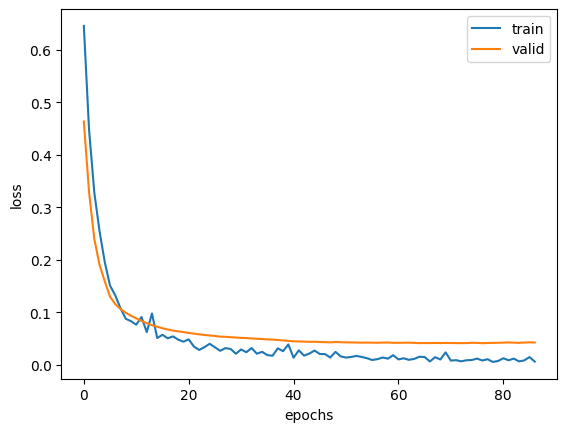

In [45]:
ConvNeXtBase_model.compile(loss='categorical_crossentropy', 
                  optimizer=tf.keras.optimizers.AdamW(learning_rate=1e-4),
                  metrics=['accuracy'])
model_path = "./model/ConvNeXtBase_catndog.keras"
check_point = ModelCheckpoint(model_path, save_best_only=True, monitor='val_loss', verbose=1)
early_stop = EarlyStopping(monitor='val_loss', patience=10, restore_best_weights=True, verbose=1)
ConvNeXtBase_history = ConvNeXtBase_model.fit(train_gen2, epochs=1000, validation_data=valid_gen2,
                           callbacks=[early_stop, check_point])
plt.plot(ConvNeXtBase_history.history['loss'])
plt.plot(ConvNeXtBase_history.history['val_loss'])
plt.xlabel('epochs')
plt.ylabel('loss')
plt.legend(['train', 'valid'])
plt.show()

7/7 ━━━━━━━━━━━━━━━━━━━━ 14s 1s/step 

[전체 Validation Accuracy] 0.5204
1/1 ━━━━━━━━━━━━━━━━━━━━ 7s 7s/step


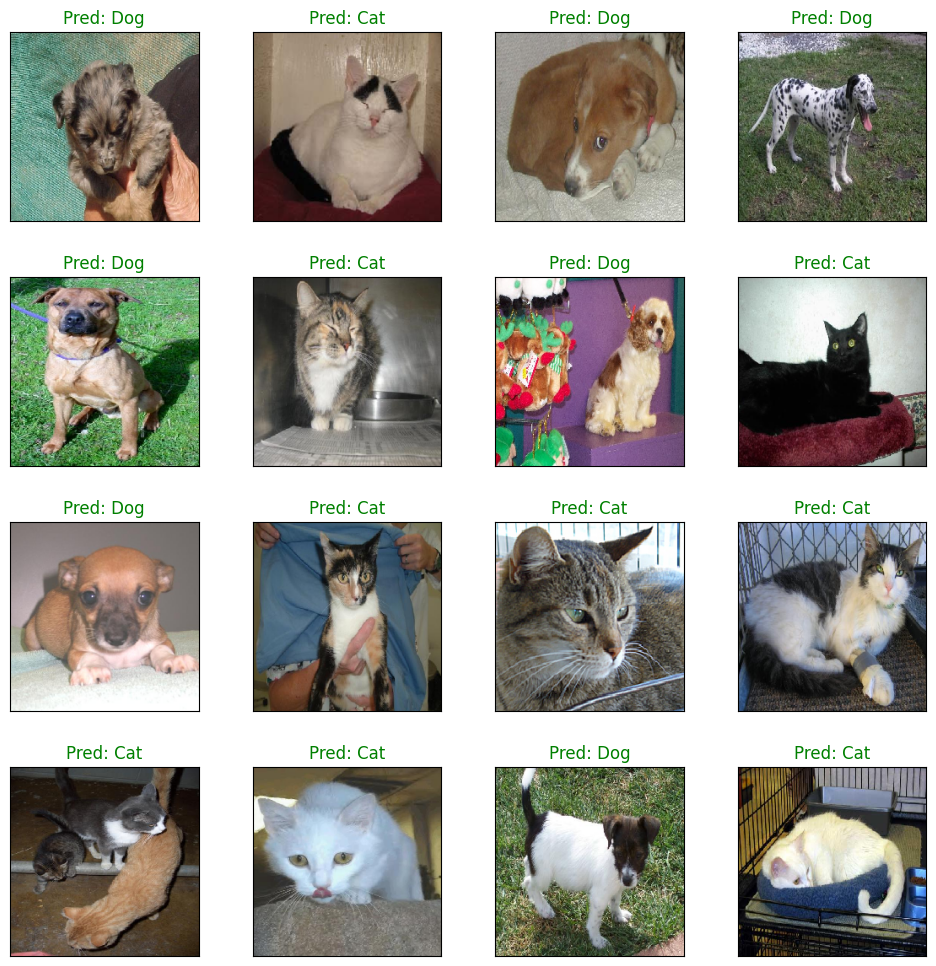

7/7 ━━━━━━━━━━━━━━━━━━━━ 15s 897ms/step - accuracy: 0.9898 - loss: 0.0411

[모델 평가 결과] Loss: 0.0411, Accuracy: 0.9898


In [47]:
# Best 모델 로드
ConvNeXtBase_best_model = load_model("./model/ConvNeXtBase_catndog.keras")

# 클래스 이름 추출
class_indices = valid_gen2.class_indices
class_names = [k for k, v in sorted(class_indices.items(), key=lambda x: x[1])]

# ✅ [1] 전체 validation dataset으로 예측 및 정확도 계산
cnn_pred = ConvNeXtBase_best_model.predict(valid_gen2, verbose=1)
pred_values = np.argmax(cnn_pred, axis=1)
true_values = valid_gen2.classes  # 전체 validation 레이블

# 정확도 출력
acc = accuracy_score(true_values, pred_values)
print(f"\n[전체 Validation Accuracy] {acc:.4f}")

# ✅ [2] 소량 배치만 시각화용으로 가져오기
small_batch, label_batch = next(valid_gen2)
small_pred = ConvNeXtBase_best_model.predict(small_batch)
small_pred_values = np.argmax(small_pred, axis=1)
small_true_values = np.argmax(label_batch, axis=1)

# ✅ 시각화 (최대 16장)
fig = plt.figure(figsize=(12, 12))
fig.subplots_adjust(hspace=0.3)
num_images = min(16, small_batch.shape[0])

for i in range(num_images):
    ax = fig.add_subplot(4, 4, i + 1, xticks=[], yticks=[])
    ax.imshow(small_batch[i].astype("uint8"))  # ConvNeXt는 0~255 이미지 입력
    pred_label = class_names[small_pred_values[i]]
    true_label = class_names[small_true_values[i]]
    color = 'green' if pred_label == true_label else 'red'
    ax.set_title(f"Pred: {pred_label}", color=color, fontsize=12)
plt.show()

# ✅ [3] 전체 validation 데이터로 loss, accuracy 평가
loss, acc = ConvNeXtBase_best_model.evaluate(valid_gen2, verbose=1)
print(f"\n[모델 평가 결과] Loss: {loss:.4f}, Accuracy: {acc:.4f}")
    